# 04. Generalizace polynomického modelu 

## Cvičení:

1. Zhodnoťte vliv velikosti trénovacích dat na generalizaci modelu. 

2. Vyhodnoťte vliv šumu v datech na generalizaci modelu. 

3. Zobecněte polynomický model zjednodušením od vysokého stupně (přístup shora dolů).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(0)

/home/lukas/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Data

In [2]:
# Generování dat 
def fun(x, noise):
    """Základní funkce"""
    return .6 * np.sin(x*6) + x + (x ** .8) * noise

def train_test_data(n_samples, noise_factor): 
    """Generování"""
    
    # train 
    np.random.seed(0)
    X_train = np.sort(np.random.rand(n_samples))
    noise_train = np.random.rand(n_samples) * noise_factor
    y_train = fun(X_train, noise_train) 
    X_train = X_train.reshape(-1, 1)
    
    # test 
    X_test = np.sort(np.random.rand(n_samples))
    noise_test = np.random.rand(n_samples) * noise_factor
    y_test = fun(X_test, noise_test)
    X_test = X_test.reshape(-1, 1)
    
    return X_train, y_train, X_test, y_test

In [3]:
# Příprava dat
n_samples = 10
noise_factor = 0.9

X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)

In [4]:
X_train.shape

(10, 1)

In [5]:
y_train.shape

(10,)

In [6]:
X_test.shape

(10, 1)

In [7]:
# Základní funkce
X_fun = np.linspace(0, 1, 100)
noise_fun = np.ones(100) / 2. * noise_factor
y_fun = fun(X_fun, noise_fun)

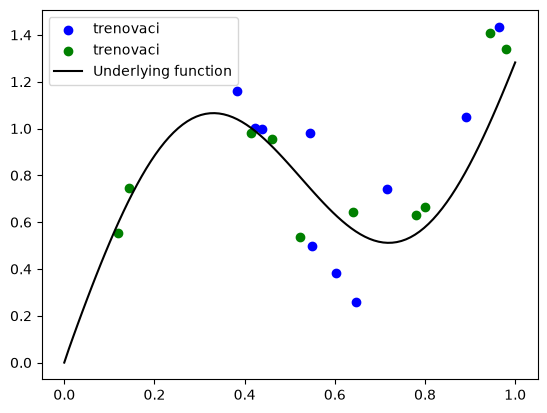

In [12]:
# Vykreslete základní funkci   
plt.scatter(X_train, y_train, label='trenovaci', color='blue') 
plt.scatter(X_test, y_test, label='trenovaci', color='green') 
plt.plot(X_fun, y_fun, label='Underlying function', color='black')
plt.legend()

In [19]:
# Parametrizujte polynomický model (stupeň = 10)
stupen = 10
poly_feat = PolynomialFeatures(degree = stupen)
X_train_poly = poly_feat.fit_transform(X_train) 

In [20]:
X_train_poly.shape

(10, 11)

In [22]:
y_train.reshape(-1, 1).shape

(10, 1)

In [23]:
model = LinearRegression()
model.fit(X_train_poly, y_train.reshape(-1, 1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 11)","[[ -0. ,-1294.97, 3304.08,...,-2350.71,-2873.79, 2582.37]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[170.16]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[2.4 ,0.41,0.07,...,0. ,0. ,0. ]"


In [47]:
y_train_poly_pred = model.predict(X_train_poly)
y_train_poly_pred.shape

(10, 1)

In [48]:
# plt.scatter(y_train, y_train_poly_pred)

In [49]:
# Vyhodnoťte přesnost trénování modelu 
MSE_train = mean_squared_error(y_train, y_train_poly_pred)
print(f'MSE trenovani: {round(MSE_train, 4)}') 

MSE trenovani: 0.0105


In [50]:
X_test_poly = poly_feat.fit_transform(X_test)
X_test_poly.shape

(10, 11)

In [51]:
# Vyhodnoťte přesnost testovani modelu 
y_test_poly_pred = model.predict(X_test_poly)
MSE_test = mean_squared_error(y_test, y_test_poly_pred)
print(f'MSE testovani: {round(MSE_test, 4)}') 

MSE testovani: 537.6086


In [53]:
# Generalizační chyba  
MSE_gen = MSE_test - MSE_train
MSE_gen

537.5981365339937

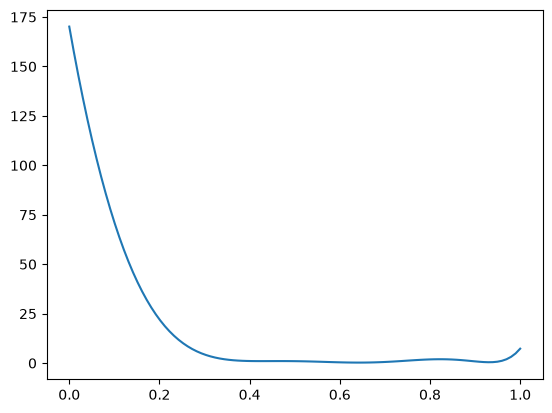

In [64]:
# Priprava pro vzkresleni modelu
X_model = np.linspace(0.0, 1.0, 100)
X_model_poly = poly_feat.fit_transform(X_model.reshape(-1, 1))
# X_model_poly.shape
y_model_poly = model.predict(X_model_poly) 
# y_model_poly.shape
# plt.plot(X_model, y_model_poly)

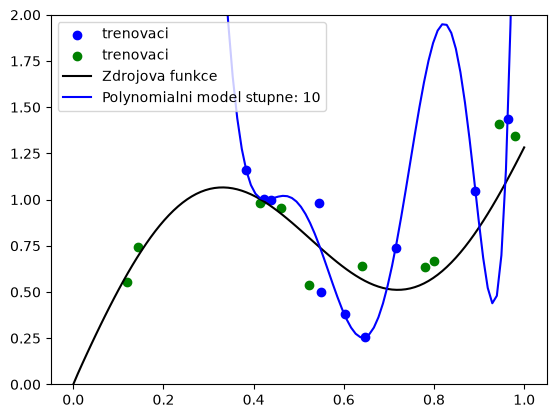

In [67]:
# Vykreslete model 
plt.scatter(X_train, y_train, label='trenovaci', color='blue') 
plt.scatter(X_test, y_test, label='trenovaci', color='green') 
plt.plot(X_fun, y_fun, label='Zdrojova funkce', color='black')
plt.plot(X_model, y_model_poly, label=f'Polynomialni model stupne: {stupen}', color='blue') 
plt.ylim(0, 2.0)
plt.legend()

### **Cvičení 1:** Vyhodnocení vlivu velikosti dat na zobecnění modelu

* Zvyšte parametr `n_samples` z 10 na 50, 100, 200 a 500.
* Jaký vliv má velikost trénovacích dat na výkonnost jeho modelu při použití modelu vyššího stupně, než je potřeba? 
* Jak důležité je mít dostatek vzorků?

In [74]:
# doporučení: vytvořte funkci která parametrizuje poly model 
# na základě trénovacích vstupů a definice stupňe polynomu
# a vrací model, poly_features, a výsledky evaluace modelu 

def train_evaluate_poly(X_train, y_train, X_test, y_test, deg): 
    """Trénování a testování polynomického modelu"""
    # priprava dat 
    poly_feat = PolynomialFeatures(degree = deg)
    X_train_poly = poly_feat.fit_transform(X_train) 
    
    # fit 
    model = LinearRegression()
    model.fit(X_train_poly, y_train.reshape(-1, 1))
    
    # MSE_train, print 
    y_train_poly_pred = model.predict(X_train_poly)
    MSE_train = mean_squared_error(y_train, y_train_poly_pred)
    print(f'MSE trenovani: {round(MSE_train, 4)}') 
    
    # MSE test, print 
    X_test_poly = poly_feat.fit_transform(X_test) 
    y_test_poly_pred = model.predict(X_test_poly)
    MSE_test = mean_squared_error(y_test, y_test_poly_pred)
    print(f'MSE testovani: {round(MSE_test, 4)}') 

    # Generalizacni rozdil 
    MSE_gen = MSE_test - MSE_train
    print(f'Generalizacni rozdil: {round(MSE_gen, 6)}') 
    
    return model 

In [83]:
noise_factor = 0.9
deg = 10
n_samples = 500  
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)
model = train_evaluate_poly(X_train, y_train, X_test, y_test, deg)

MSE trenovani: 0.0252
MSE testovani: 0.0288
Generalizacni rozdil: 0.003587


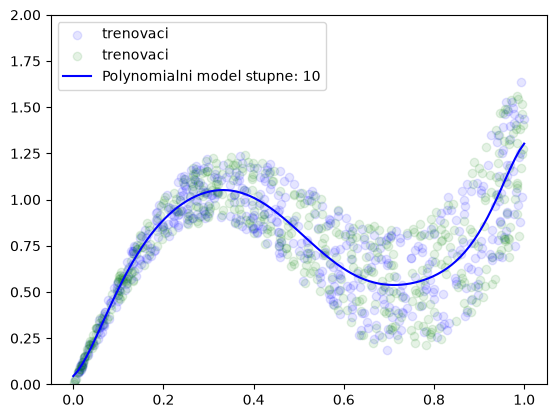

In [85]:
# Vykreslete model
# Priprava pro vzkresleni modelu
X_model = np.linspace(0.0, 1.0, 100)
X_model_poly = poly_feat.fit_transform(X_model.reshape(-1, 1))
# X_model_poly.shape
y_model_poly = model.predict(X_model_poly) 
# Plot 
plt.scatter(X_train, y_train, label='trenovaci', color='blue', alpha = 0.1) 
plt.scatter(X_test, y_test, label='trenovaci', color='green', alpha = 0.1) 
# plt.plot(X_fun, y_fun, label='Zdrojova funkce', color='black')
plt.plot(X_model, y_model_poly, label=f'Polynomialni model stupne: {stupen}', color='blue') 
plt.ylim(0, 2.0)
plt.legend()

### **Cvičení 2:** Vyhodnocení vlivu šumu na zobecnění modelu
* Snížení parametru šumu `noise_factor` z 0,9 na 0,5 a 0,1
* Jaký vliv má šum v trénovacích datech na zobecnění modelu? 
* Dále zvyšte parametr `n_samples` z na 200 a ponechte `noise_factor` na hodnotě 10 % = 0,1. Jak vypadá model?

In [92]:
noise_factor = 0.1
deg = 10
n_samples = 20 
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)
model = train_evaluate_poly(X_train, y_train, X_test, y_test, deg)

MSE trenovani: 0.0002
MSE testovani: 0.0006
Generalizacni rozdil: 0.000447


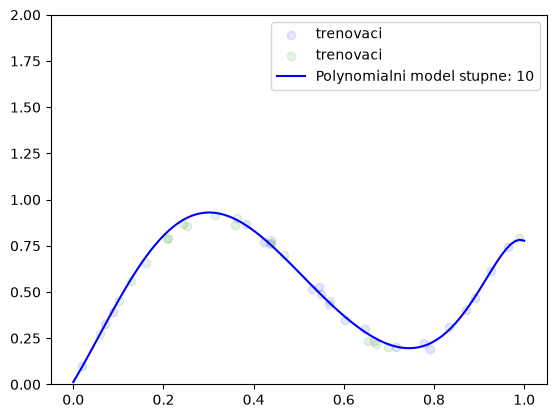

In [93]:
# Vykreslete model
# Priprava pro vzkresleni modelu
X_model = np.linspace(0.0, 1.0, 100)
X_model_poly = poly_feat.fit_transform(X_model.reshape(-1, 1))
# X_model_poly.shape
y_model_poly = model.predict(X_model_poly) 
# Plot 
plt.scatter(X_train, y_train, label='trenovaci', color='blue', alpha = 0.1) 
plt.scatter(X_test, y_test, label='trenovaci', color='green', alpha = 0.1) 
# plt.plot(X_fun, y_fun, label='Zdrojova funkce', color='black')
plt.plot(X_model, y_model_poly, label=f'Polynomialni model stupne: {stupen}', color='blue') 
plt.ylim(0, 2.0)
plt.legend()

### **Cvičení 3:** Zjednodušení modelu pro lepší generalizaci
* Snižte stupeň polynomu modelu `degree` z 10 na vhodnou hodnotu, aby se minimalizoval rozdíl mezi testovacím a trénovacím modelem. Aby byl model dobře generalizován. 

In [99]:
noise_factor = 0.5
deg = 4
n_samples = 30 
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)
model = train_evaluate_poly(X_train, y_train, X_test, y_test, deg)

MSE trenovani: 0.0082
MSE testovani: 0.0084
Generalizacni rozdil: 0.000205


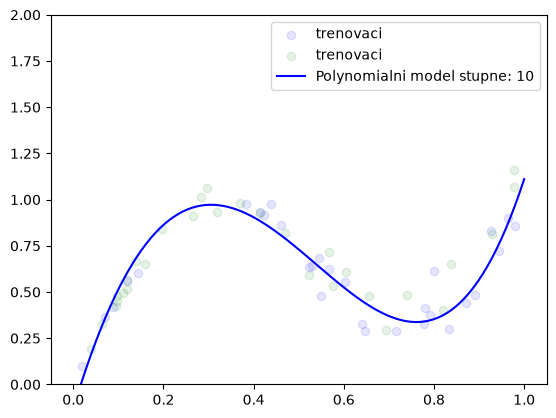

In [100]:
# Vykreslete výsledek
# Priprava pro vzkresleni modelu
poly_feat = PolynomialFeatures(degree = deg)
X_model = np.linspace(0.0, 1.0, 100)
X_model_poly = poly_feat.fit_transform(X_model.reshape(-1, 1))
# X_model_poly.shape
y_model_poly = model.predict(X_model_poly) 
# Plot 
plt.scatter(X_train, y_train, label='trenovaci', color='blue', alpha = 0.1) 
plt.scatter(X_test, y_test, label='trenovaci', color='green', alpha = 0.1) 
# plt.plot(X_fun, y_fun, label='Zdrojova funkce', color='black')
plt.plot(X_model, y_model_poly, label=f'Polynomialni model stupne: {stupen}', color='blue') 
plt.ylim(0, 2.0)
plt.legend()